# Fake News Detection using Logistic Regression

In [1]:

import pandas as pd
import numpy as np
import re
import string
import pickle
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# UPLOADING

In [2]:
fake = pd.read_csv('Fake.csv')
true = pd.read_csv('True.csv')
fake['class']=0
true['class']=1

In [3]:
data = pd.concat([fake,true],axis=0)
data=data[['text','class']]
data=data.sample(frac=1,random_state=42).reset_index(drop=True)

In [4]:
def clean_text(text):
    text=str(text).lower()
    text=re.sub(r'https?://\S+|www\.\S+','',text)
    text=re.sub(r'<.*?>','',text)
    text=re.sub(r'[%s]' % re.escape(string.punctuation),'',text)
    text=re.sub(r'\w*\d\w*','',text)
    text=re.sub(r'\s+',' ',text).strip()
    return text

data['text']=data['text'].apply(clean_text)

## Visualization

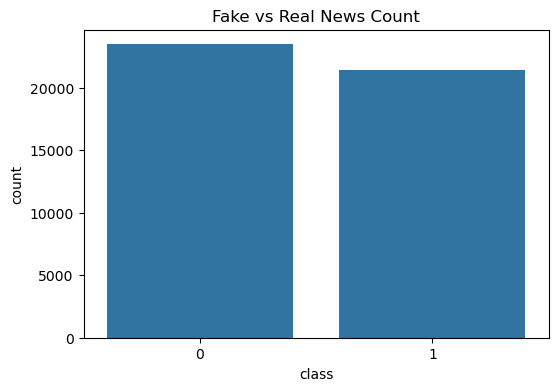

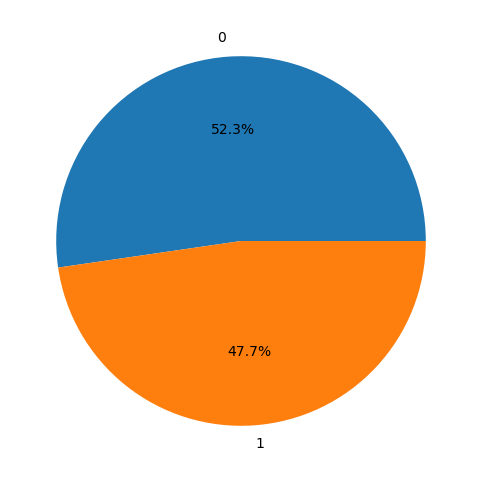

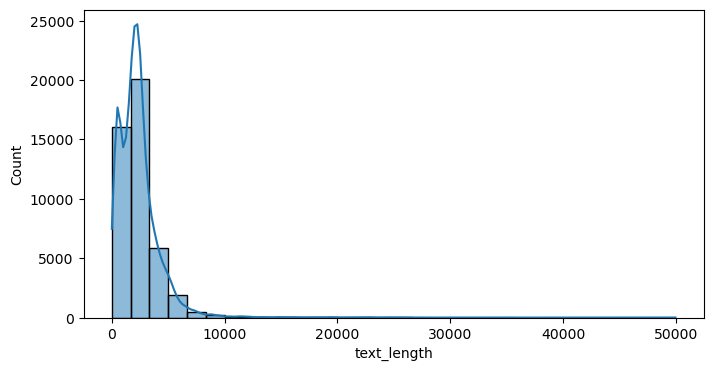

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(x='class',data=data)
plt.title('Fake vs Real News Count')
plt.show()

plt.figure(figsize=(6,6))
data['class'].value_counts().plot.pie(autopct='%1.1f%%')
plt.ylabel('')
plt.show()

data['text_length']=data['text'].apply(len)
plt.figure(figsize=(8,4))
sns.histplot(data['text_length'],bins=30,kde=True)
plt.show()

In [6]:
X=data['text']
y=data['class']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

vectorizer=TfidfVectorizer(stop_words='english',max_df=0.7)
X_train_vec=vectorizer.fit_transform(X_train)
X_test_vec=vectorizer.transform(X_test)

In [7]:
model=LogisticRegression(max_iter=1000)
model.fit(X_train_vec,y_train)
y_pred=model.predict(X_test_vec)

print('Accuracy:',accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

Accuracy: 0.9815590200445434
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      5863
           1       0.98      0.98      0.98      5362

    accuracy                           0.98     11225
   macro avg       0.98      0.98      0.98     11225
weighted avg       0.98      0.98      0.98     11225



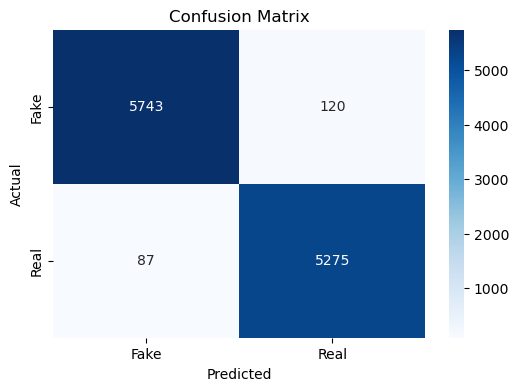

In [8]:
cm=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['Fake','Real'],yticklabels=['Fake','Real'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [10]:
import joblib
joblib.dump(model, "model_new.pkl")
joblib.dump(vectorizer, "vectorizer_new.pkl")

['vectorizer_new.pkl']